## 1. Library

In [1]:
import pandas as pd
import re
import nltk
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

## 2. Pre-Processing (sama untuk semua rasio)

In [2]:
df = pd.read_csv('all-data.csv', encoding='latin-1', header=None, names=['sentiment', 'text'])
df.head()

,sentiment,text
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


In [3]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to C:\Users\HP
[nltk_data]     Victus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\HP
[nltk_data]     Victus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\HP
[nltk_data]     Victus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\HP
[nltk_data]     Victus\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\HP
[nltk_data]     Victus\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [4]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    lematized = [lemmatizer.lemmatize(word) for word in tokens]
    return ' '.join(lematized)

df['processed_text'] = df['text'].apply(preprocess_text)
df.drop(['text'], axis=1, inplace=True)
df.head()

,sentiment,processed_text
0,neutral,according gran company plan move production ru...
1,neutral,technopolis plan develop stage area less squar...
2,negative,international electronic industry company elco...
3,positive,new production plant company would increase ca...
4,positive,according company updated strategy year baswar...


In [5]:
print("Contoh Data Sentimen NETRAL:")
print(df[df['sentiment'] == 'neutral']['processed_text'].head(10))
print("\nContoh Data Sentimen POSITIF:")
print(df[df['sentiment'] == 'positive']['processed_text'].head(10))
print("\nContoh Data Sentimen NEGATIF:")
print(df[df['sentiment'] == 'negative']['processed_text'].head(10))

Contoh Data Sentimen NETRAL:
0     according gran company plan move production ru...
1     technopolis plan develop stage area less squar...
58    request finnish medium company alma medium new...
59    sweden gallerix accumulated sek denominated sa...
60    company support global customer developing new...
61    investment place atrium plan expand moscow market
62    new agreement continuation theagreement signed...
64    june sold percent stake nordstjernan investmen...
67    stock exchange announcement july basware share...
69    new plant planned electricity generation capac...
Name: processed_text, dtype: str

Contoh Data Sentimen POSITIF:
3     new production plant company would increase ca...
4     according company updated strategy year baswar...
5     financing aspocomp growth aspocomp aggressivel...
6     last quarter componenta net sale doubled eurm ...
7     third quarter net sale increased eur mn operat...
8     operating profit rose eur mn eur mn correspond...
9     opera

In [6]:
le = LabelEncoder()
df['sentiment'] = le.fit_transform(df['sentiment'])
df.head()

,sentiment,processed_text
0,1,according gran company plan move production ru...
1,1,technopolis plan develop stage area less squar...
2,0,international electronic industry company elco...
3,2,new production plant company would increase ca...
4,2,according company updated strategy year baswar...


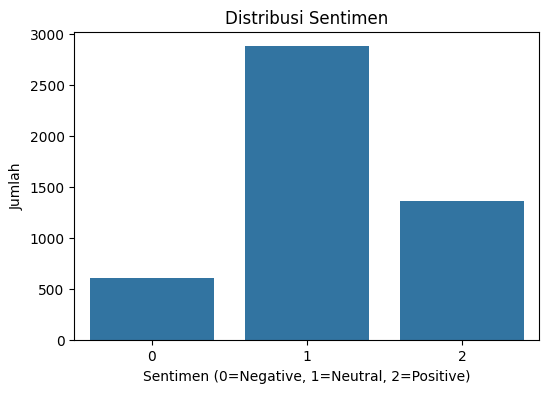

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df)
plt.title('Distribusi Sentimen')
plt.xlabel('Sentimen (0=Negative, 1=Neutral, 2=Positive)')
plt.ylabel('Jumlah')
plt.show()

## 3. Tokenisasi (sama untuk semua rasio)

In [8]:
X = df['processed_text']
y = df['sentiment']

In [9]:
max_words = 1000
max_len = 50

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X)

X_seq = tokenizer.texts_to_sequences(X)
X_pad = pad_sequences(X_seq,maxlen=max_len,padding='post',truncating='post')

# Inisialisasi dictionary untuk menyimpan hasil semua rasio

In [10]:
results_dict = {}

def save_ratio_result(ratio_name, accuracy, loss):
    results_dict[ratio_name] = {
        'accuracy': round(float(accuracy), 4),
        'loss': round(float(loss), 4),
    }
    return results_dict


def plot_ratio_summary(results_dict):
    if not results_dict:
        print('Belum ada hasil rasio yang disimpan.')
        return

    summary_df = pd.DataFrame(results_dict).T.reset_index()
    summary_df = summary_df.rename(columns={'index': 'ratio'})
    summary_df = summary_df.sort_values('ratio').reset_index(drop=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.barplot(data=summary_df, x='ratio', y='accuracy', palette='viridis', ax=axes[0])
    axes[0].set_title('Accuracy per Rasio')
    axes[0].set_xlabel('Rasio Split')
    axes[0].set_ylabel('Accuracy')
    axes[0].tick_params(axis='x', rotation=45)

    sns.barplot(data=summary_df, x='ratio', y='loss', palette='rocket', ax=axes[1])
    axes[1].set_title('Loss per Rasio')
    axes[1].set_xlabel('Rasio Split')
    axes[1].set_ylabel('Loss')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

    print(summary_df.to_string(index=False))

## 4. Eksperimen Rasio Split 90:10 (train:test)

### Split Data

In [11]:
x_train, x_test, y_train, y_test = train_test_split(X_pad, y, test_size=0.1, random_state=42, stratify=y)

In [12]:
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(4361, 50) (485, 50) (4361,) (485,)


### Encoding & Class Weight

In [13]:
y_train_categorical = to_categorical(y_train)
y_test_categorical = to_categorical(y_test)

In [14]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict

{0: np.float64(2.6771025168815226),
 1: np.float64(0.5610446417084781),
 2: np.float64(1.184732409671285)}

### Arsitektur Model LSTM

In [15]:
model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=128,
        mask_zero=True
    ),
    LSTM(64),Dropout(0.5),Dense(32, activation='relu'),Dense(3, activation='softmax')
])

### Training

In [16]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(x_train,y_train_categorical,epochs=20,batch_size=32,validation_split=0.2, callbacks=[early_stop])

Epoch 1/20


109/109 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6167 - loss: 0.8988 - val_accuracy: 0.6896 - val_loss: 0.7367
Epoch 2/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7193 - loss: 0.6707 - val_accuracy: 0.7102 - val_loss: 0.6745
Epoch 3/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8062 - loss: 0.5167 - val_accuracy: 0.7308 - val_loss: 0.6571
Epoch 4/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8498 - loss: 0.4073 - val_accuracy: 0.7113 - val_loss: 0.7474
Epoch 5/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8704 - loss: 0.3573 - val_accuracy: 0.7354 - val_loss: 0.7756
Epoch 6/20
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8905 - loss: 0.2967 - val_accuracy: 0.7159 - val_loss: 0.8465


### Evaluasi

In [17]:
loss, acc = model.evaluate(x_test,y_test_categorical)
print("Accuracy:", acc)
save_ratio_result('90:10', acc, loss)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6969 - loss: 0.7122
Accuracy: 0.6969072222709656


{'90:10': {'accuracy': 0.6969, 'loss': 0.7122}}

In [18]:
y_pred = model.predict(x_test)
y_pred_class = y_pred.argmax(axis=1)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [19]:
print(classification_report(y_test,y_pred_class))

              precision    recall  f1-score   support

           0       0.59      0.57      0.58        61
           1       0.74      0.86      0.80       288
           2       0.59      0.40      0.48       136

    accuracy                           0.70       485
   macro avg       0.64      0.61      0.62       485
weighted avg       0.68      0.70      0.68       485



### Confusion Matrix, Kurva Training, dan ROC

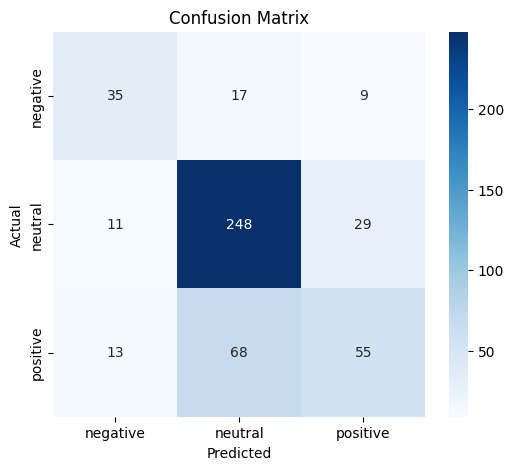

In [20]:
conf_matrix = confusion_matrix(y_test, y_pred_class)
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

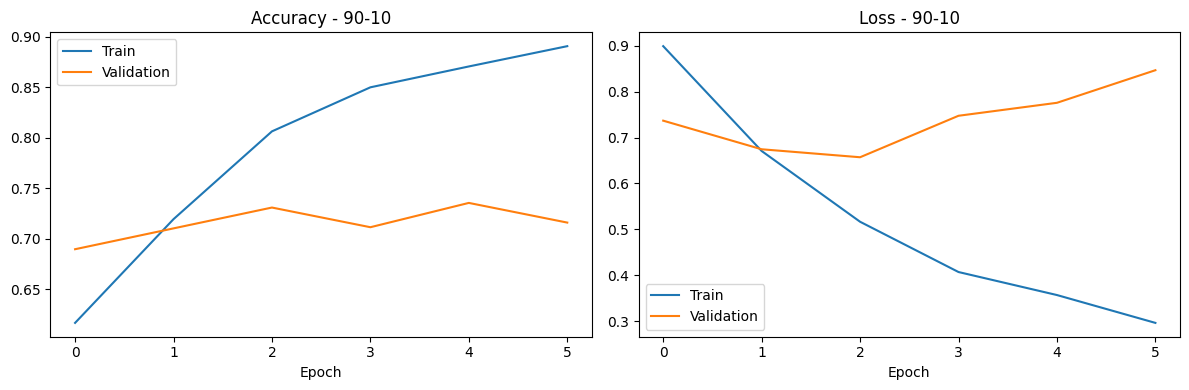

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title(f'Accuracy - 90-10')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title(f'Loss - 90-10')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

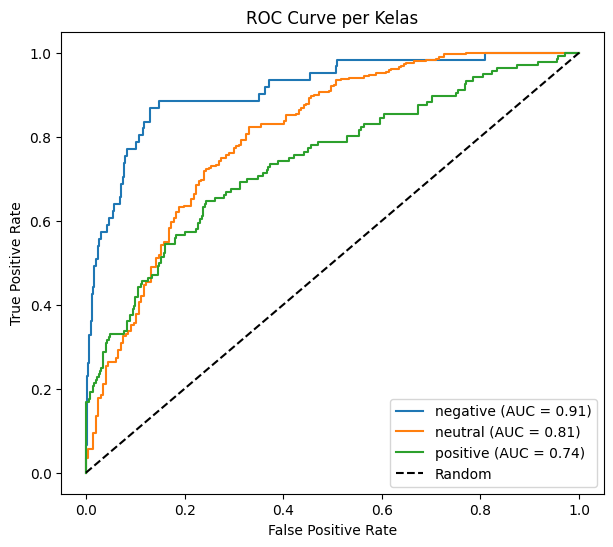

In [22]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_true = y_test.values
y_pred_proba = y_pred
n_classes = len(le.classes_)
class_names = le.classes_

y_true_bin = label_binarize(y_true, classes=range(n_classes))

plt.figure(figsize=(7,6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve per Kelas')
plt.legend()
plt.show()

## 4. Eksperimen Rasio Split 80:20 (train:test)

### Split Data

In [23]:
x_train, x_test, y_train, y_test = train_test_split(X_pad, y, test_size=0.2, random_state=42, stratify=y)

In [24]:
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(3876, 50) (970, 50) (3876,) (970,)


### Encoding & Class Weight

In [25]:
y_train_categorical = to_categorical(y_train)
y_test_categorical = to_categorical(y_test)

In [26]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict

{0: np.float64(2.6749482401656315),
 1: np.float64(0.5610073816760747),
 2: np.float64(1.1853211009174311)}

### Arsitektur Model LSTM

In [27]:
model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=128,
        mask_zero=True
    ),
    LSTM(64),Dropout(0.5),Dense(32, activation='relu'),Dense(3, activation='softmax')
])

### Training

In [28]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(x_train,y_train_categorical,epochs=20,batch_size=32,validation_split=0.2, callbacks=[early_stop])

Epoch 1/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6077 - loss: 0.9033 - val_accuracy: 0.6907 - val_loss: 0.7599
Epoch 2/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7281 - loss: 0.6652 - val_accuracy: 0.7410 - val_loss: 0.6411
Epoch 3/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8190 - loss: 0.4808 - val_accuracy: 0.7423 - val_loss: 0.6829
Epoch 4/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8510 - loss: 0.3919 - val_accuracy: 0.7539 - val_loss: 0.7428
Epoch 5/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.8690 - loss: 0.3450 - val_accuracy: 0.7436 - val_loss: 0.8298


### Evaluasi

In [29]:
loss, acc = model.evaluate(x_test,y_test_categorical)
print("Accuracy:", acc)
save_ratio_result('80:20', acc, loss)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7031 - loss: 0.7223
Accuracy: 0.7030927538871765


{'90:10': {'accuracy': 0.6969, 'loss': 0.7122},
 '80:20': {'accuracy': 0.7031, 'loss': 0.7223}}

In [30]:
y_pred = model.predict(x_test)
y_pred_class = y_pred.argmax(axis=1)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [31]:
print(classification_report(y_test,y_pred_class))

              precision    recall  f1-score   support

           0       0.58      0.50      0.54       121
           1       0.75      0.86      0.80       576
           2       0.61      0.47      0.53       273

    accuracy                           0.70       970
   macro avg       0.65      0.61      0.62       970
weighted avg       0.69      0.70      0.69       970



### Confusion Matrix, Kurva Training, dan ROC

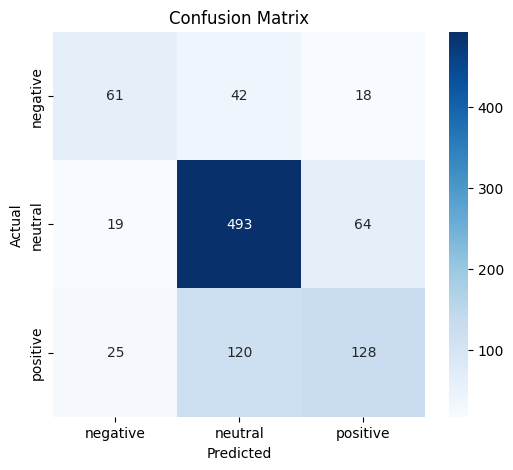

In [32]:
conf_matrix = confusion_matrix(y_test, y_pred_class)
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

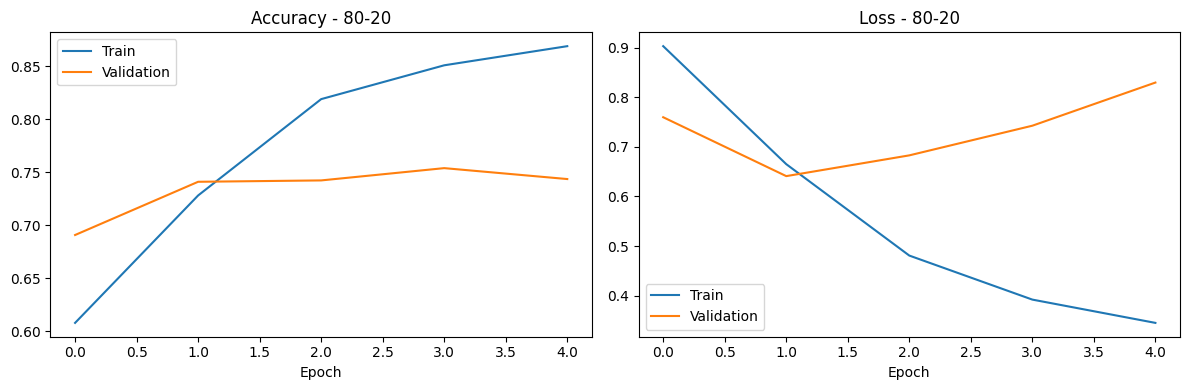

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title(f'Accuracy - 80-20')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title(f'Loss - 80-20')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

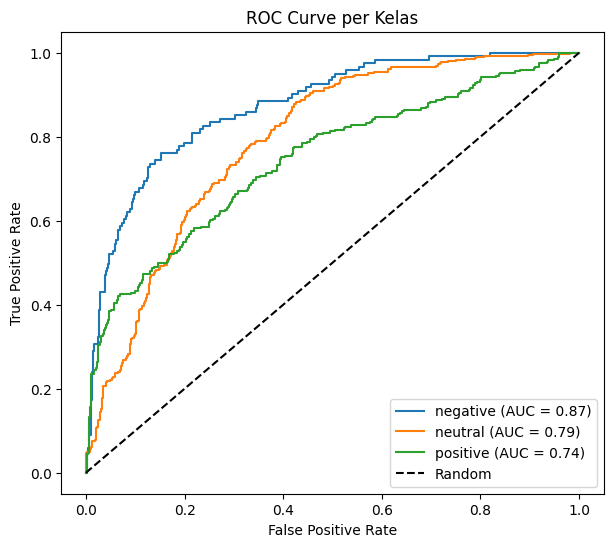

In [34]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_true = y_test.values
y_pred_proba = y_pred
n_classes = len(le.classes_)
class_names = le.classes_

y_true_bin = label_binarize(y_true, classes=range(n_classes))

plt.figure(figsize=(7,6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve per Kelas')
plt.legend()
plt.show()

## 4. Eksperimen Rasio Split 70:30 (train:test)

### Split Data

In [35]:
x_train, x_test, y_train, y_test = train_test_split(X_pad, y, test_size=0.3, random_state=42, stratify=y)

In [36]:
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(3392, 50) (1454, 50) (3392,) (1454,)


### Encoding & Class Weight

In [37]:
y_train_categorical = to_categorical(y_train)
y_test_categorical = to_categorical(y_test)

In [38]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict

{0: np.float64(2.672970843183609),
 1: np.float64(0.5611248966087676),
 2: np.float64(1.1851851851851851)}

### Arsitektur Model LSTM

In [39]:
model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=128,
        mask_zero=True
    ),
    LSTM(64),Dropout(0.5),Dense(32, activation='relu'),Dense(3, activation='softmax')
])

### Training

In [40]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(x_train,y_train_categorical,epochs=20,batch_size=32,validation_split=0.2, callbacks=[early_stop])

Epoch 1/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5923 - loss: 0.9315 - val_accuracy: 0.6819 - val_loss: 0.7637
Epoch 2/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.6978 - loss: 0.6964 - val_accuracy: 0.7305 - val_loss: 0.6574
Epoch 3/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8043 - loss: 0.5139 - val_accuracy: 0.7658 - val_loss: 0.6658
Epoch 4/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8474 - loss: 0.4182 - val_accuracy: 0.7452 - val_loss: 0.6895
Epoch 5/20
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8824 - loss: 0.3377 - val_accuracy: 0.7541 - val_loss: 0.8095


### Evaluasi

In [41]:
loss, acc = model.evaluate(x_test,y_test_categorical)
print("Accuracy:", acc)
save_ratio_result('70:30', acc, loss)

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6747 - loss: 0.7413
Accuracy: 0.6746904850006104


{'90:10': {'accuracy': 0.6969, 'loss': 0.7122},
 '80:20': {'accuracy': 0.7031, 'loss': 0.7223},
 '70:30': {'accuracy': 0.6747, 'loss': 0.7413}}

In [42]:
y_pred = model.predict(x_test)
y_pred_class = y_pred.argmax(axis=1)

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [43]:
print(classification_report(y_test,y_pred_class))

              precision    recall  f1-score   support

           0       0.62      0.13      0.22       181
           1       0.77      0.84      0.80       864
           2       0.50      0.56      0.53       409

    accuracy                           0.67      1454
   macro avg       0.63      0.51      0.52      1454
weighted avg       0.67      0.67      0.65      1454



### Confusion Matrix, Kurva Training, dan ROC

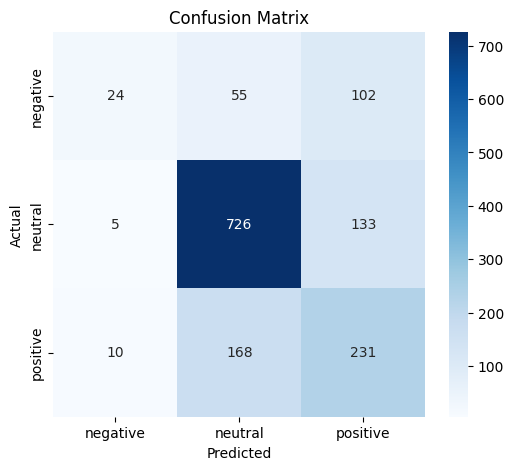

In [44]:
conf_matrix = confusion_matrix(y_test, y_pred_class)
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

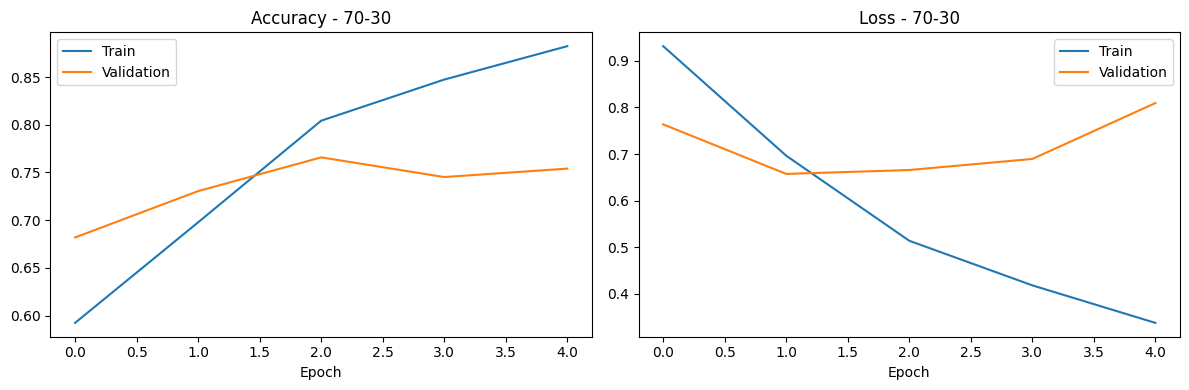

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title(f'Accuracy - 70-30')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title(f'Loss - 70-30')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

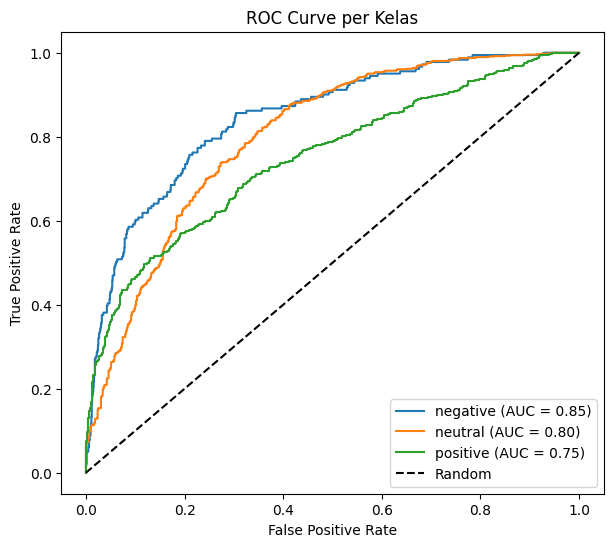

In [46]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_true = y_test.values
y_pred_proba = y_pred
n_classes = len(le.classes_)
class_names = le.classes_

y_true_bin = label_binarize(y_true, classes=range(n_classes))

plt.figure(figsize=(7,6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve per Kelas')
plt.legend()
plt.show()

## 4. Eksperimen Rasio Split 60:40 (train:test)

### Split Data

In [47]:
x_train, x_test, y_train, y_test = train_test_split(X_pad, y, test_size=0.4, random_state=42, stratify=y)

In [48]:
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(2907, 50) (1939, 50) (2907,) (1939,)


### Encoding & Class Weight

In [49]:
y_train_categorical = to_categorical(y_train)
y_test_categorical = to_categorical(y_test)

In [50]:
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict

{0: np.float64(2.6767955801104972),
 1: np.float64(0.5610885929357267),
 2: np.float64(1.184596577017115)}

### Arsitektur Model LSTM

In [51]:
model = Sequential([
    Embedding(
        input_dim=max_words,
        output_dim=128,
        mask_zero=True
    ),
    LSTM(64),Dropout(0.5),Dense(32, activation='relu'),Dense(3, activation='softmax')
])

### Training

In [52]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(x_train,y_train_categorical,epochs=20,batch_size=32,validation_split=0.2, callbacks=[early_stop])

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5871 - loss: 0.9437 - val_accuracy: 0.6753 - val_loss: 0.7717
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6822 - loss: 0.7158 - val_accuracy: 0.6907 - val_loss: 0.7234
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7923 - loss: 0.5366 - val_accuracy: 0.7096 - val_loss: 0.6802
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8551 - loss: 0.3978 - val_accuracy: 0.7079 - val_loss: 0.7354
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8963 - loss: 0.3157 - val_accuracy: 0.7113 - val_loss: 0.7792
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9080 - loss: 0.2636 - val_accuracy: 0.6838 - val_loss: 0.8988


### Evaluasi

In [53]:
loss, acc = model.evaluate(x_test,y_test_categorical)
print("Accuracy:", acc)
save_ratio_result('60:40', acc, loss)

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6968 - loss: 0.7575
Accuracy: 0.6967508792877197


{'90:10': {'accuracy': 0.6969, 'loss': 0.7122},
 '80:20': {'accuracy': 0.7031, 'loss': 0.7223},
 '70:30': {'accuracy': 0.6747, 'loss': 0.7413},
 '60:40': {'accuracy': 0.6968, 'loss': 0.7575}}

In [54]:
y_pred = model.predict(x_test)
y_pred_class = y_pred.argmax(axis=1)

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [55]:
print(classification_report(y_test,y_pred_class))

              precision    recall  f1-score   support

           0       0.50      0.53      0.52       242
           1       0.77      0.83      0.80      1152
           2       0.61      0.49      0.54       545

    accuracy                           0.70      1939
   macro avg       0.63      0.62      0.62      1939
weighted avg       0.69      0.70      0.69      1939



### Confusion Matrix, Kurva Training, dan ROC

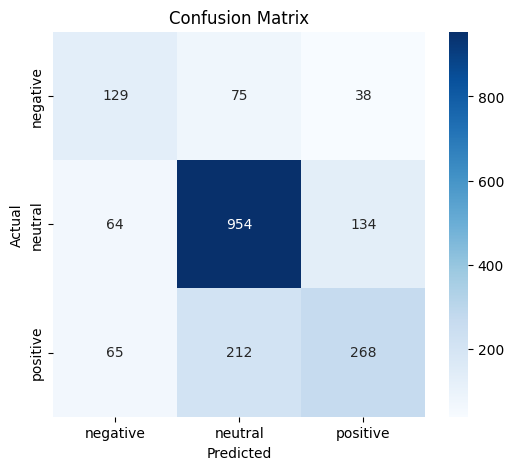

In [56]:
conf_matrix = confusion_matrix(y_test, y_pred_class)
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

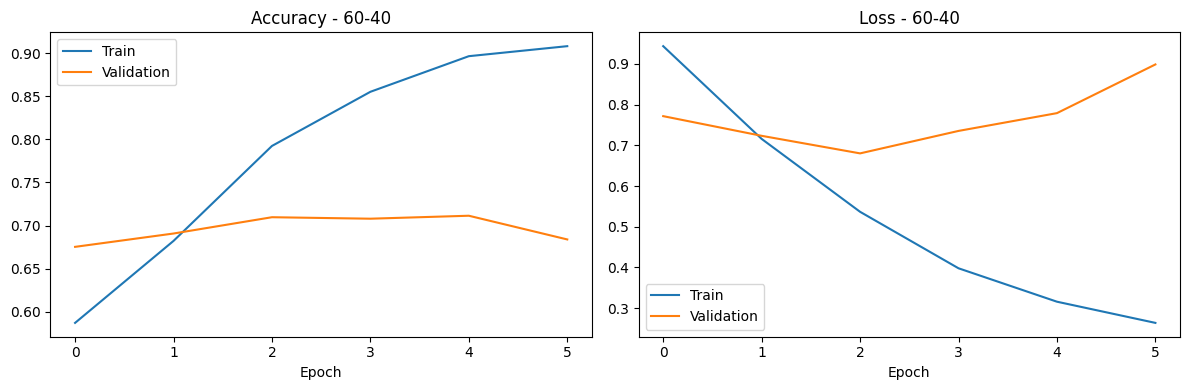

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title(f'Accuracy - 60-40')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title(f'Loss - 60-40')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

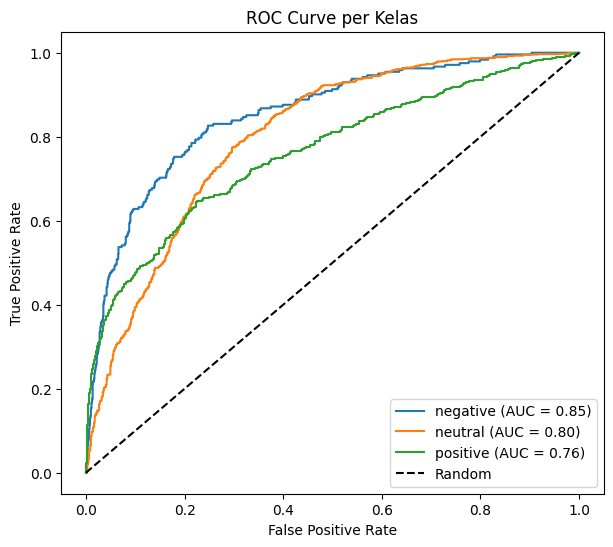

In [58]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_true = y_test.values
y_pred_proba = y_pred
n_classes = len(le.classes_)
class_names = le.classes_

y_true_bin = label_binarize(y_true, classes=range(n_classes))

plt.figure(figsize=(7,6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve per Kelas')
plt.legend()
plt.show()

C:\Users\HP Victus\AppData\Local\Temp\ipykernel_17284\3499127301.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x='ratio', y='accuracy', palette='viridis', ax=axes[0])
C:\Users\HP Victus\AppData\Local\Temp\ipykernel_17284\3499127301.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_df, x='ratio', y='loss', palette='rocket', ax=axes[1])


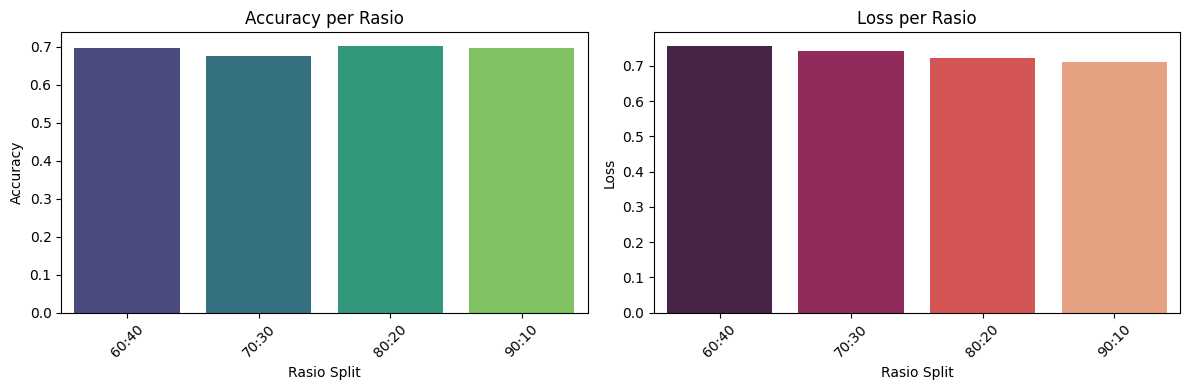

ratio  accuracy   loss
60:40    0.6968 0.7575
70:30    0.6747 0.7413
80:20    0.7031 0.7223
90:10    0.6969 0.7122


In [59]:
plot_ratio_summary(results_dict)